# PRACTICAL SESSION 05:
Simulating the dynamics of a massive perturber in a Plummer sphere

## IMPORT MODULES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform

# 1 - INPUT GENERATION:
Refer to PS04 for the generation of a stable Plummer sphere. Use as starting point one of the inputs or the outputs

## CHOSING UNITS

In [2]:
# Chosen units (same name as in astropy https://docs.astropy.org/en/stable/units/#module-astropy.units.astrophys)
my_u = ["pc","year","M_sun"]

# Physical constants converted to chosen units
G = const.G.to(my_u[0] + "^3/(" + my_u[1] + "^2" + my_u[2]+")").value
c = const.c.to(my_u[0] + "/" + my_u[1]).value
print("G =",G,"c =",c)

# Conversion constants between physical and internal units
R0 = 1.
M0 = 2 # R0**3 / (G * T0**2)
T0 = np.sqrt(R0**3 / (G * M0)) # 1000

G = 4.498502151469552e-15 c = 0.30660139378555057


## SET MASSIVE PERTURBER

In [4]:
# Reading file

file_out = '.txt'

time_rows = []
m_rows, r_rows, v_rows = [], [], []
with open(file_out, "r") as file:
    lines = file.readlines()
    N = int(lines[0])
    n = 3 * N + 3 # 'block' length
    m = 3     # number of rows to skip (i.e. lines containing n. bodies and time)
    for i in range(0, len(lines), n):  # move through rows every n rows
        time_rows.extend(lines[i+2:i+m])
        m_rows.extend(lines[i+m:i+N+3])
        r_rows.extend(lines[i+N+3:i+2*N+3])
        v_rows.extend(lines[i+2*N+3:i+n])

time = np.loadtxt(time_rows)

In [5]:
# FETCHING DATA

m = np.loadtxt(m_rows) # masses

r = np.loadtxt(r_rows) # positions
d = np.linalg.norm(r, axis=1) # distance from center

v = np.loadtxt(v_rows) # velocities
vm = np.linalg.norm(v, axis=1)


# MOVE TO CM FRAME

x, y, z = r[:, 0].reshape(time.size, N), r[:, 1].reshape(time.size, N), r[:, 2].reshape(time.size, N)

_, x_cm = np.meshgrid(np.zeros(N), x.mean(axis=1))
_, y_cm = np.meshgrid(np.zeros(N), y.mean(axis=1))
_, z_cm = np.meshgrid(np.zeros(N), z.mean(axis=1))

x_CM = x - x_cm
y_CM = y - y_cm
z_CM = z - z_cm

d_CM = np.sqrt(x_CM**2 + y_CM**2 + z_CM**2)

In [4]:
# Gravitational potential normalized by -U
def psi(r):
  return 1 / np.sqrt(1 + r**2)
# NOTE: the density is proportional to psi^5


# Radius as a function of mass (useful to generate r with the inverse function method)
def radius(M):
  return 1 / np.sqrt(1 / M**(2/3) - 1)

In [5]:
rho = radius(uniform.rvs(size=N))

x = a * rho * np.sin(the) * np.cos(phi)
y = a * rho * np.sin(the) * np.sin(phi)
z = a * rho * np.cos(the)

## PRINT FILE

In [9]:
file_in = 'IF05.txt'

In [15]:
# INTEGRATION PARAMETERS (for treecode)
# NOTE: parameters must be converted in internal units

eps, alpha = 1, .05

r_ext = a #* rho.max()
M_ext = M * r_ext**3 / (r_ext**2 + a**2)**(3/2)
T_ext = 2 * np.pi * r_ext**(3/2) / np.sqrt(G * M_ext)

M_eps = M * eps**3 / (eps**2 + a**2)**(3/2)
T_eps = 2 * np.pi * eps**(3/2) / np.sqrt(G * M_eps)

t_eps = eps**(3/2) / np.sqrt(G * m[0])

print('M(a) =', round(M_ext / M0, 2), '\tT_orb =', round(T_ext / T0, 2))
print('M(eps) =', round(M_eps / M0, 2), '\tT_eps =', round(T_eps / T0, 2))
print('m_p =', round(m[0] / M0, 2), '\tt_eps =', round(t_eps / T0, 2))
print('Conversion constants: R0 =', R0, 'T0 =', T0, 'M0 =', M0)

M(a) = 1767.77 	T_orb = 4.73
M(eps) = 4.93 	T_eps = 2.83
m_p = 0.0 	t_eps = 14909601.35
Conversion constants: R0 = 1.0 T0 = 10542680.273053497 M0 = 2


In [10]:
# FOR TREECODE

m = m / M0

x = x / R0
y = y / R0
z = z / R0

vx = vx / R0 * T0
vy = vy / R0 * T0
vz = vz / R0 * T0

n_dim = 3
time_in = 0 # initial time

out_r = np.column_stack((x, y, z))
out_v = np.column_stack((vx, vy, vz))
with open(file_in, 'w') as file:
    file.write(f'{N+1}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time_in}\n')
    for i in m:
        file.write(f'{i}\n')
    np.savetxt(file, out_r)
    np.savetxt(file, out_v)

# 2 - ANALYSIS

In [4]:
# Reading file

file_out = 'OF05-2.txt'

n = 3 * N + 3 # 'block' length
m = 3     # number of rows to skip (i.e. lines containing n. bodies and time)

time_rows = []
m_rows, r_rows, v_rows = [], [], []
with open(file_out, "r") as file:
    lines = file.readlines()
    for i in range(0, len(lines), n):  # move through rows every n rows
        time_rows.extend(lines[i+2:i+m])
        m_rows.extend(lines[i+m:i+N+3])
        r_rows.extend(lines[i+N+3:i+2*N+3])
        v_rows.extend(lines[i+2*N+3:i+n])

time = np.loadtxt(time_rows)

In [5]:
# FETCHING DATA

m = np.loadtxt(m_rows) # masses

r = np.loadtxt(r_rows) # positions
d = np.linalg.norm(r, axis=1) # distance from center

v = np.loadtxt(v_rows) # velocities
vm = np.linalg.norm(v, axis=1)


# MOVE TO CM FRAME

x, y, z = r[:, 0].reshape(time.size, N), r[:, 1].reshape(time.size, N), r[:, 2].reshape(time.size, N)

_, x_cm = np.meshgrid(np.zeros(N), x.mean(axis=1))
_, y_cm = np.meshgrid(np.zeros(N), y.mean(axis=1))
_, z_cm = np.meshgrid(np.zeros(N), z.mean(axis=1))

x_CM = x - x_cm
y_CM = y - y_cm
z_CM = z - z_cm

d_CM = np.sqrt(x_CM**2 + y_CM**2 + z_CM**2)

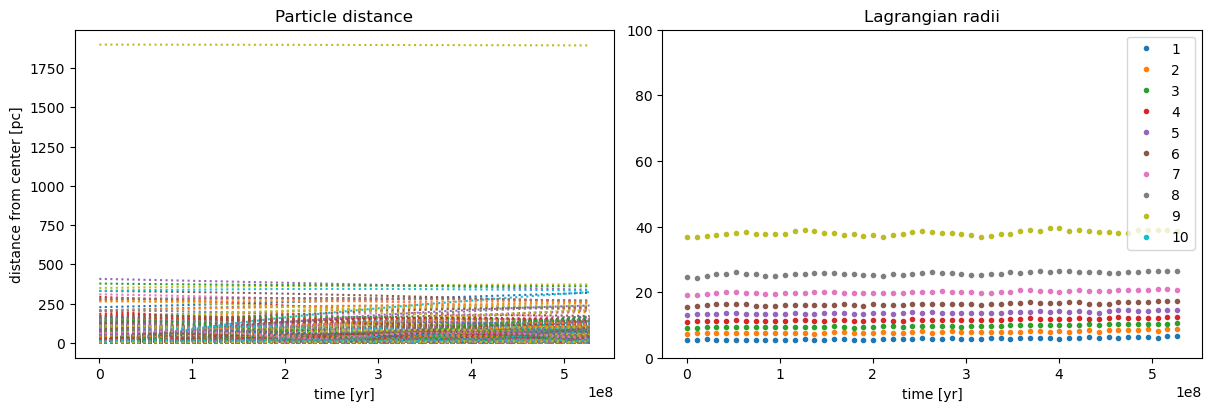

In [26]:
# Plotting distance vs time in the CF

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_mtx = d.reshape((time.size, N))
d_sort = np.sort(d_mtx, axis=1)

# Distance from the CF center of each p.cle
for i in range(N):
    #ax.plot(time, d[i::N], '.')
    ax.plot(time * T0, d_mtx[:, i], ':')

ax.set_title('Particle distance')
ax.set_xlabel('time [yr]')
ax.set_ylabel('distance from center [pc]')

# Lagrangian radii in the CF
for i in range(10):
    bx.plot(time * T0, d_sort[:, int((i+1) * N / 10) - 1], '.', label=i+1)

bx.set_ylim(0, 100)

bx.set_title('Lagrangian radii')
bx.set_xlabel('time [yr]')
bx.legend()

plt.show()

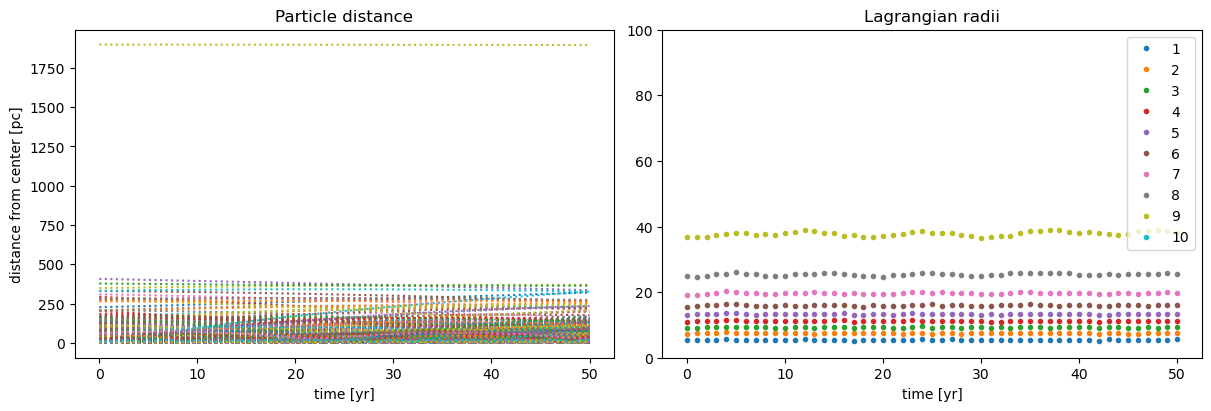

In [25]:
# Plotting distance vs time in the system center (i.e. the CM)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_s = np.sort(d_CM, axis=1)

# Distance of each p.cle from the CM
for i in range(N):
    ax.plot(time, d_CM[:, i], ':')
    
ax.set_title('Particle distance')
ax.set_xlabel('time [yr]')
ax.set_ylabel('distance from center [pc]')

# Lagrangian radii
for i in range(10):
    bx.plot(time, d_s[:, int((i+1) * N / 10) - 1], '.', label=i+1)

bx.set_ylim(0, 100)

bx.set_title('Lagrangian radii')
bx.set_xlabel('time [yr]')
bx.legend()

plt.show()